In [187]:
import pandas as pd
import numpy as np
import pypsa
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Configuration

In [188]:
data_dir = Path("../data")

mapping_pypsa_carriers = {
    "Combined-Cycle Gas": "Fossil Gas",
    "Load shedding": None,
    "Offshore Wind (AC)": "Wind Offshore",
    "Offshore Wind (DC)": "Wind Offshore",
    "Onshore Wind": "Wind Onshore",
    "Open-Cycle Gas": "Fossil Gas",
    "Run of River": "Hydro Run-of-river and poundage",
    "Solar": "Solar",
    "biomass": "Biomass",
    "nuclear": "Nuclear",
    "coal": "Fossil Hard coal",
    "lignite": "Fossil Brown coal/Lignite",
    "oil": "Fossil Oil",
    "solar-hsat": "Solar",
    "Pumped Hydro Storage": "Hydro Pumped Storage",
    "Reservoir & Dam": "Hydro Water Reservoir",
}


start_date = (pd.Timestamp("2022-01-01"),)
end_date = (pd.Timestamp("2022-12-31 23:00"),)


country = "DE"

resampling_rule = "W"

x_length = 6

phi = 1.618

data_dir = Path("../data")

n = pypsa.Network(data_dir / "network_files" / "hindcast-dyn-rolling-wy2022.nc")

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [189]:
# Color mapping for plotting

color_dict = n.carriers["color"].to_dict()

mapping_color = {
    "offwind-ac": "Wind Offshore",
    "offwind-dc": "Wind Offshore",
    "onwind": "Wind Onshore",
    "solar": "Solar",
    "solar-hsat": "Solar",
    "CCGT": "Fossil Gas",
    "OCGT": "Fossil Gas",
    "PHS": "Hydro Pumped Storage",
    "biomass": "Biomass",
    "coal": "Fossil Hard coal",
    "geothermal": "Geothermal",
    "hydro": "Hydro Water Reservoir",
    "lignite": "Fossil Brown coal/Lignite",
    "nuclear": "Nuclear",
    "oil": "Fossil Oil",
    "ror": "Hydro Run-of-river and poundage",
}

color_dict_new = {}

for original_name, new_name in mapping_color.items():
    # Use the color from the original carrier
    if original_name in color_dict:
        color_dict_new[new_name] = color_dict[original_name]


color_dict_new['Other'] = 'tab:red'
color_dict_new

{'Wind Offshore': '#74c6f2',
 'Wind Onshore': '#235ebc',
 'Solar': '#fdb915',
 'Fossil Gas': '#e0986c',
 'Hydro Pumped Storage': '#51dbcc',
 'Biomass': '#baa741',
 'Fossil Hard coal': '#545454',
 'Geothermal': '#ba91b1',
 'Hydro Water Reservoir': '#298c81',
 'Fossil Brown coal/Lignite': '#826837',
 'Nuclear': '#ff8c00',
 'Fossil Oil': '#c9c9c9',
 'Hydro Run-of-river and poundage': '#3dbfb0',
 'Other': 'tab:red'}

# PyPSA generation plot

In [190]:
supply_stats = n.statistics.supply(groupby=["bus", "carrier"], groupby_time=False) / 1000
country_supply = supply_stats.xs(country, level="bus")
country_generators_and_storage = country_supply.loc[["Generator", "StorageUnit"], :]
country_dispatch_raw = country_generators_and_storage.T.droplevel(0, axis=1)

ignored_carriers = [
    col for col, target in mapping_pypsa_carriers.items() if target is None and col in country_dispatch_raw.columns
]
country_dispatch_raw = country_dispatch_raw.drop(columns=ignored_carriers)

carrier_rename = {
    col: target
    for col, target in mapping_pypsa_carriers.items()
    if target is not None and col in country_dispatch_raw.columns
}
country_dispatch = country_dispatch_raw.rename(columns=carrier_rename)
country_dispatch = country_dispatch.T.groupby(level=0).sum().T  # merg


if resampling_rule:
    country_dispatch_res = country_dispatch.resample(resampling_rule).sum()
else:
    country_dispatch_res = country_dispatch

country_dispatch_res.head()

carrier,Biomass,Fossil Brown coal/Lignite,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Solar,Wind Offshore,Wind Onshore
snapshot,,,,,,,,,,
2022-01-02,71.744622,1041.683265,0.000044,432.543156,0.000013,0.000000,98.001996,99.958168,319.439192,1334.581469
2022-01-09,251.106184,3643.065361,0.000208,2864.022381,0.000188,61.285201,510.656158,378.475087,1042.432139,4541.303298
2022-01-16,251.106199,3645.892795,1625.988078,3040.560943,0.000146,10.037090,523.309466,441.200953,756.720459,1727.769424
2022-01-23,251.106206,3645.892824,1130.582649,3034.210909,0.000000,31.030929,542.340643,363.778076,957.975639,3580.022792
2022-01-30,251.106206,3641.845074,812.689866,2520.201307,0.000000,53.759237,543.815788,377.926504,1037.832697,4516.377475


In [191]:
country_dispatch_res.index

DatetimeIndex(['2022-01-02', '2022-01-09', '2022-01-16', '2022-01-23',
               '2022-01-30', '2022-02-06', '2022-02-13', '2022-02-20',
               '2022-02-27', '2022-03-06', '2022-03-13', '2022-03-20',
               '2022-03-27', '2022-04-03', '2022-04-10', '2022-04-17',
               '2022-04-24', '2022-05-01', '2022-05-08', '2022-05-15',
               '2022-05-22', '2022-05-29', '2022-06-05', '2022-06-12',
               '2022-06-19', '2022-06-26', '2022-07-03', '2022-07-10',
               '2022-07-17', '2022-07-24', '2022-07-31', '2022-08-07',
               '2022-08-14', '2022-08-21', '2022-08-28', '2022-09-04',
               '2022-09-11', '2022-09-18', '2022-09-25', '2022-10-02',
               '2022-10-09', '2022-10-16', '2022-10-23', '2022-10-30',
               '2022-11-06', '2022-11-13', '2022-11-20', '2022-11-27',
               '2022-12-04', '2022-12-11', '2022-12-18', '2022-12-25',
               '2023-01-01'],
              dtype='datetime64[ns]', name='sna

In [192]:
country_dispatch.sum()

carrier
Biomass                             13091.942908
Fossil Brown coal/Lignite          181111.516473
Fossil Gas                           9682.478614
Fossil Hard coal                   116544.352033
Fossil Oil                           4888.401077
Hydro Pumped Storage                 2458.050208
Hydro Run-of-river and poundage     17282.147658
Solar                               70218.755179
Wind Offshore                       34954.213130
Wind Onshore                       116544.432649
dtype: float64

# ENTSOE

In [193]:
entsoe_raw = pd.read_csv(
    data_dir / "generation" / f"generation_{country}_hourly_data.csv",
    index_col=0,
    parse_dates=True,
)

entsoe_filtered_raw = entsoe_raw[pd.Timestamp(start_date[0], tz="UTC") : pd.Timestamp(end_date[0], tz="UTC")]

entsoe_filtered_raw.head()

,"('Biomass', 'Actual Aggregated')","('Fossil Brown coal/Lignite', 'Actual Aggregated')","('Fossil Coal-derived gas', 'Actual Aggregated')","('Fossil Gas', 'Actual Aggregated')","('Fossil Gas', 'Actual Consumption')","('Fossil Hard coal', 'Actual Aggregated')","('Fossil Oil', 'Actual Aggregated')","('Fossil Oil', 'Actual Consumption')","('Geothermal', 'Actual Aggregated')","('Hydro Pumped Storage', 'Actual Aggregated')",...,"('Other', 'Actual Aggregated')","('Other renewable', 'Actual Aggregated')","('Other renewable', 'Actual Consumption')","('Solar', 'Actual Aggregated')","('Solar', 'Actual Consumption')","('Waste', 'Actual Aggregated')","('Wind Offshore', 'Actual Aggregated')","('Wind Onshore', 'Actual Aggregated')","('Wind Onshore', 'Actual Consumption')",Biomass
2022-01-01 00:00:00+00:00,4253.333333,3540.666667,NaN,3414.333333,NaN,2048.666667,279.0,NaN,26.0,402.00,...,333.0,132.0,NaN,2.0,0.0,851.333333,5804.333333,24166.00,0.0,NaN
2022-01-01 01:00:00+00:00,4258.000000,3495.000000,NaN,3408.750000,NaN,2033.250000,279.0,NaN,26.0,379.75,...,333.0,133.0,NaN,2.0,0.0,845.250000,5548.000000,23188.75,0.0,NaN
2022-01-01 02:00:00+00:00,4263.000000,3504.750000,NaN,3414.000000,NaN,2023.750000,279.0,NaN,27.0,321.25,...,333.0,132.5,NaN,2.0,0.0,841.750000,5382.750000,22113.50,0.0,NaN
2022-01-01 03:00:00+00:00,4267.250000,3537.500000,NaN,3428.750000,NaN,2013.250000,279.0,NaN,27.0,244.25,...,333.0,131.5,NaN,2.0,0.0,835.500000,5586.500000,20620.75,0.0,NaN
2022-01-01 04:00:00+00:00,4280.250000,3767.000000,NaN,3421.250000,NaN,2014.000000,279.0,NaN,27.0,212.75,...,333.0,131.5,NaN,2.0,0.0,841.750000,4531.250000,19587.75,0.0,NaN


In [194]:
entsoe_filtered_raw.columns

Index(['('Biomass', 'Actual Aggregated')',
       '('Fossil Brown coal/Lignite', 'Actual Aggregated')',
       '('Fossil Coal-derived gas', 'Actual Aggregated')',
       '('Fossil Gas', 'Actual Aggregated')',
       '('Fossil Gas', 'Actual Consumption')',
       '('Fossil Hard coal', 'Actual Aggregated')',
       '('Fossil Oil', 'Actual Aggregated')',
       '('Fossil Oil', 'Actual Consumption')',
       '('Geothermal', 'Actual Aggregated')',
       '('Hydro Pumped Storage', 'Actual Aggregated')',
       '('Hydro Pumped Storage', 'Actual Consumption')',
       '('Hydro Run-of-river and poundage', 'Actual Aggregated')',
       '('Hydro Water Reservoir', 'Actual Aggregated')',
       '('Hydro Water Reservoir', 'Actual Consumption')',
       '('Nuclear', 'Actual Aggregated')', '('Nuclear', 'Actual Consumption')',
       '('Other', 'Actual Aggregated')',
       '('Other renewable', 'Actual Aggregated')',
       '('Other renewable', 'Actual Consumption')',
       '('Solar', 'Actual Aggregat

In [195]:
entsoe_filtered_raw.sum()

('Biomass', 'Actual Aggregated')                            3.802634e+07
('Fossil Brown coal/Lignite', 'Actual Aggregated')          1.035259e+08
('Fossil Coal-derived gas', 'Actual Aggregated')            6.512500e+02
('Fossil Gas', 'Actual Aggregated')                         4.591159e+07
('Fossil Gas', 'Actual Consumption')                        0.000000e+00
('Fossil Hard coal', 'Actual Aggregated')                   6.289539e+07
('Fossil Oil', 'Actual Aggregated')                         2.788978e+06
('Fossil Oil', 'Actual Consumption')                        0.000000e+00
('Geothermal', 'Actual Aggregated')                         2.032400e+05
('Hydro Pumped Storage', 'Actual Aggregated')               1.015594e+07
('Hydro Pumped Storage', 'Actual Consumption')              1.359417e+07
('Hydro Run-of-river and poundage', 'Actual Aggregated')    1.130533e+07
('Hydro Water Reservoir', 'Actual Aggregated')              1.556329e+06
('Hydro Water Reservoir', 'Actual Consumption')    

In [196]:
keep_cols = [
    "('Biomass', 'Actual Aggregated')",
    "('Fossil Brown coal/Lignite', 'Actual Aggregated')",
    #"('Fossil Coal-derived gas', 'Actual Aggregated')",
    "('Fossil Gas', 'Actual Aggregated')",
    "('Fossil Hard coal', 'Actual Aggregated')",
    "('Fossil Oil', 'Actual Aggregated')",
    "('Geothermal', 'Actual Aggregated')",
    "('Hydro Pumped Storage', 'Actual Aggregated')",
    #"('Hydro Pumped Storage', 'Actual Consumption')",
    "('Hydro Run-of-river and poundage', 'Actual Aggregated')",
    "('Hydro Water Reservoir', 'Actual Aggregated')",
    "('Nuclear', 'Actual Aggregated')",
    "('Other', 'Actual Aggregated')",
    "('Other renewable', 'Actual Aggregated')",
    "('Solar', 'Actual Aggregated')",
    "('Waste', 'Actual Aggregated')",
    "('Wind Offshore', 'Actual Aggregated')",
    "('Wind Onshore', 'Actual Aggregated')",
]
entsoe_filtered = entsoe_filtered_raw[keep_cols].copy()

mapping_entsoe_pypsa = {
    "('Biomass', 'Actual Aggregated')": "Biomass",
    "('Fossil Brown coal/Lignite', 'Actual Aggregated')": "Fossil Brown coal/Lignite",
    "('Fossil Coal-derived gas', 'Actual Aggregated')": "Fossil Gas",
    "('Fossil Gas', 'Actual Aggregated')": "Fossil Gas",
    "('Fossil Hard coal', 'Actual Aggregated')": "Fossil Hard coal",
    "('Fossil Oil', 'Actual Aggregated')": "Fossil Oil",
    "('Geothermal', 'Actual Aggregated')": "Geothermal",
    "('Hydro Pumped Storage', 'Actual Aggregated')": "Hydro Pumped Storage",
    #"('Hydro Pumped Storage', 'Actual Consumption')": ,
    "('Hydro Run-of-river and poundage', 'Actual Aggregated')": "Hydro Run-of-river and poundage",
    "('Hydro Water Reservoir', 'Actual Aggregated')": "Hydro Water Reservoir",
    "('Nuclear', 'Actual Aggregated')": "Nuclear",
    "('Other', 'Actual Aggregated')": "Other",
    "('Other renewable', 'Actual Aggregated')": "Other",
    "('Solar', 'Actual Aggregated')": "Solar",
    "('Waste', 'Actual Aggregated')": "Biomass",
    "('Wind Offshore', 'Actual Aggregated')": "Wind Offshore",
    "('Wind Onshore', 'Actual Aggregated')": "Wind Onshore",
}

entsoe_filtered.sum()

('Biomass', 'Actual Aggregated')                            3.802634e+07
('Fossil Brown coal/Lignite', 'Actual Aggregated')          1.035259e+08
('Fossil Gas', 'Actual Aggregated')                         4.591159e+07
('Fossil Hard coal', 'Actual Aggregated')                   6.289539e+07
('Fossil Oil', 'Actual Aggregated')                         2.788978e+06
('Geothermal', 'Actual Aggregated')                         2.032400e+05
('Hydro Pumped Storage', 'Actual Aggregated')               1.015594e+07
('Hydro Run-of-river and poundage', 'Actual Aggregated')    1.130533e+07
('Hydro Water Reservoir', 'Actual Aggregated')              1.556329e+06
('Nuclear', 'Actual Aggregated')                            3.282362e+07
('Other', 'Actual Aggregated')                              2.303491e+06
('Other renewable', 'Actual Aggregated')                    1.087412e+06
('Solar', 'Actual Aggregated')                              5.598763e+07
('Waste', 'Actual Aggregated')                     

In [197]:
entsoe_clean = entsoe_filtered.rename(columns=mapping_entsoe_pypsa) /1000
entsoe_clean.columns

Index(['Biomass', 'Fossil Brown coal/Lignite', 'Fossil Gas',
       'Fossil Hard coal', 'Fossil Oil', 'Geothermal', 'Hydro Pumped Storage',
       'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Nuclear',
       'Other', 'Other', 'Solar', 'Biomass', 'Wind Offshore', 'Wind Onshore'],
      dtype='str')

In [198]:
entsoe_clean = entsoe_clean.tz_localize(None)
entsoe_clean.index

DatetimeIndex(['2022-01-01 00:00:00', '2022-01-01 01:00:00',
               '2022-01-01 02:00:00', '2022-01-01 03:00:00',
               '2022-01-01 04:00:00', '2022-01-01 05:00:00',
               '2022-01-01 06:00:00', '2022-01-01 07:00:00',
               '2022-01-01 08:00:00', '2022-01-01 09:00:00',
               ...
               '2022-12-31 14:00:00', '2022-12-31 15:00:00',
               '2022-12-31 16:00:00', '2022-12-31 17:00:00',
               '2022-12-31 18:00:00', '2022-12-31 19:00:00',
               '2022-12-31 20:00:00', '2022-12-31 21:00:00',
               '2022-12-31 22:00:00', '2022-12-31 23:00:00'],
              dtype='datetime64[us]', length=8760, freq=None)

In [199]:
entsoe_clean.head()

,Biomass,Fossil Brown coal/Lignite,Fossil Gas,Fossil Hard coal,Fossil Oil,Geothermal,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Other,Solar,Biomass,Wind Offshore,Wind Onshore
2022-01-01 00:00:00,4.253333,3.540667,3.414333,2.048667,0.279,0.026,0.40200,1.429333,0.088667,3.34700,0.333,0.1320,0.002,0.851333,5.804333,24.16600
2022-01-01 01:00:00,4.258000,3.495000,3.408750,2.033250,0.279,0.026,0.37975,1.428250,0.046750,3.34425,0.333,0.1330,0.002,0.845250,5.548000,23.18875
2022-01-01 02:00:00,4.263000,3.504750,3.414000,2.023750,0.279,0.027,0.32125,1.428250,0.031500,3.34250,0.333,0.1325,0.002,0.841750,5.382750,22.11350
2022-01-01 03:00:00,4.267250,3.537500,3.428750,2.013250,0.279,0.027,0.24425,1.426500,0.078500,3.34250,0.333,0.1315,0.002,0.835500,5.586500,20.62075
2022-01-01 04:00:00,4.280250,3.767000,3.421250,2.014000,0.279,0.027,0.21275,1.419750,0.065750,3.34725,0.333,0.1315,0.002,0.841750,4.531250,19.58775


In [200]:
country_dispatch.head()

carrier,Biomass,Fossil Brown coal/Lignite,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Solar,Wind Offshore,Wind Onshore
snapshot,,,,,,,,,,
2022-01-01 00:00:00,1.49468,21.701735,8.100000e-07,2.960343,2.700000e-07,0.0,1.983777,0.0,7.274166,30.987607
2022-01-01 01:00:00,1.49468,21.701735,8.300000e-07,2.659769,2.700000e-07,0.0,1.986250,0.0,7.273037,29.744282
2022-01-01 02:00:00,1.49468,21.701735,8.300000e-07,1.817741,2.700000e-07,0.0,1.987468,0.0,7.263849,27.809409
2022-01-01 03:00:00,1.49468,21.701735,8.300000e-07,1.712104,2.700000e-07,0.0,1.989163,0.0,7.268351,26.867846
2022-01-01 04:00:00,1.49468,21.701735,8.400000e-07,3.594575,2.700000e-07,0.0,1.990312,0.0,7.273157,24.968361


In [201]:
unique_cols = list(dict.fromkeys(entsoe_clean.columns.tolist()))
clean_data = {col: entsoe_clean[[col]].sum(axis=1) for col in unique_cols}
entsoe_dedup = pd.DataFrame(clean_data, index=entsoe_clean.index)

diff = entsoe_dedup.copy()
for col in diff.columns:
    if col in country_dispatch.columns:
        diff[col] = entsoe_dedup[col] - country_dispatch[col]
    # else: leave as entsoe value untouched

diff.head()

,Biomass,Fossil Brown coal/Lignite,Fossil Gas,Fossil Hard coal,Fossil Oil,Geothermal,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00,3.609987,-18.161068,3.414333,-0.911677,0.279,0.026,0.40200,-0.554444,0.088667,3.34700,0.4650,0.002,-1.469832,-6.821607
2022-01-01 01:00:00,3.608570,-18.206735,3.408749,-0.626519,0.279,0.026,0.37975,-0.558000,0.046750,3.34425,0.4660,0.002,-1.725037,-6.555532
2022-01-01 02:00:00,3.610070,-18.196985,3.413999,0.206009,0.279,0.027,0.32125,-0.559218,0.031500,3.34250,0.4655,0.002,-1.881099,-5.695909
2022-01-01 03:00:00,3.608070,-18.164235,3.428749,0.301146,0.279,0.027,0.24425,-0.562663,0.078500,3.34250,0.4645,0.002,-1.681851,-6.247096
2022-01-01 04:00:00,3.627320,-17.934735,3.421249,-1.580575,0.279,0.027,0.21275,-0.570562,0.065750,3.34725,0.4645,0.002,-2.741907,-5.380611


In [202]:
diff_res = diff.resample(resampling_rule).sum()

# Get prices

In [203]:
prices_dict = {}


sim_labels = {'hindcast-std',
              'hindcast-dyn',
              'hindcast-dyn-rolling'}
# Load simulation
for sim_label in sim_labels:
    file_dir = Path('../results_concat') / sim_label / 'electricity_prices' / "combined_electricity_prices.csv"

    df_sim = pd.read_csv(file_dir, index_col=0, parse_dates=True)
    df_sim = df_sim[df_sim.index.year.isin([2022])]

    prices_dict[sim_label] = df_sim

# Load benchmark
benchmark_path = data_dir / "benchmark" / "electricity_prices.csv"
df_bench = pd.read_csv(benchmark_path, index_col=0, parse_dates=True)

if df_bench.index.tz is None:
     df_bench.index = df_bench.index.tz_localize("UTC")
else:
    df_bench.index = df_bench.index.tz_convert("UTC")

df_bench = df_bench.interpolate().ffill().bfill()

df_bench = df_bench[df_bench.index.year.isin([2022])]

prices_dict["benchmark"] = df_bench
prices_dict

{'hindcast-dyn':                              AL          AT          BA          BE  \
 snapshot                                                              
 2022-01-01 00:00:00  164.710562  156.743834  156.359288  140.594888   
 2022-01-01 01:00:00  164.044772  156.743817  155.326374  135.257340   
 2022-01-01 02:00:00  160.889974  156.319970  154.661043  135.515949   
 2022-01-01 03:00:00  162.030591  156.168618  155.514276  136.505556   
 2022-01-01 04:00:00  162.458917  155.977500  155.305447  136.342516   
 ...                         ...         ...         ...         ...   
 2022-12-31 19:00:00  176.888374  173.741522  173.747036  160.907923   
 2022-12-31 20:00:00  173.835032  173.621355  173.353067  151.599910   
 2022-12-31 21:00:00  173.539161  173.657354  173.436281  151.599926   
 2022-12-31 22:00:00  173.534268  173.207571  172.289738  151.599796   
 2022-12-31 23:00:00  173.529857  172.588008  172.289721  151.599744   
 
                              BG          CH  

# That one plot

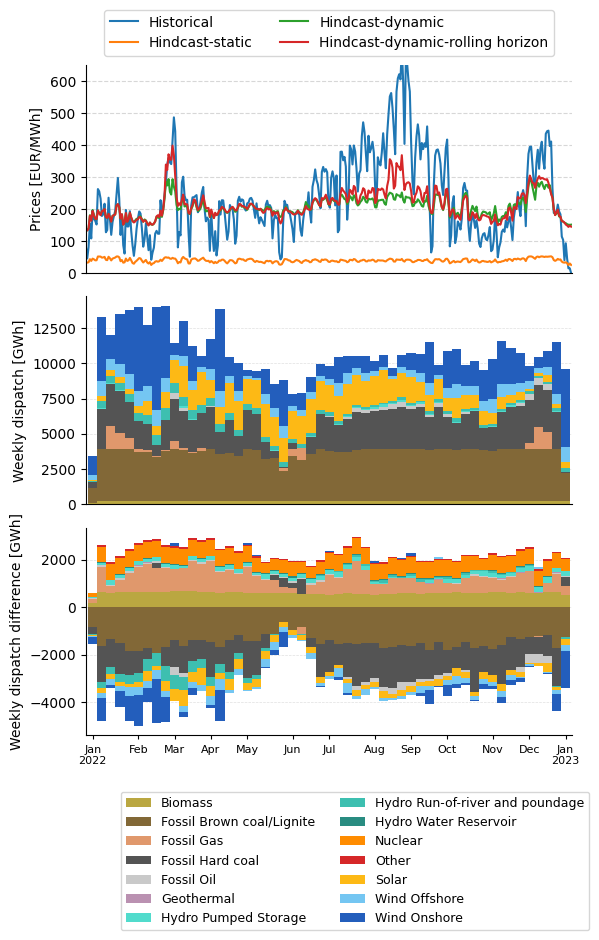

In [211]:
fig, axs = plt.subplots(
    ncols=1,
    nrows=3,
    figsize=(x_length, x_length * phi*0.8),
    sharex=False,
)

plot_order = [
    "benchmark",
    "hindcast-std",
    "hindcast-dyn",
    "hindcast-dyn-rolling",
]

for label in plot_order:
    if label not in prices_dict:
        continue
    df = prices_dict[label]

    if country not in df.columns:
        continue

    series = df[country]
    if resampling_rule:
        series = series.resample("D").mean()

    axs[0].plot(series, label=label, 
                #color=self.sim_color.get(label, None)
                )

legend_label_map = {
    "benchmark":            "Historical",
    "hindcast-std":         "Hindcast-static",
    "hindcast-dyn":         "Hindcast-dynamic",
    "hindcast-dyn-rolling": "Hindcast-dynamic-rolling horizon",
}
desired_order = ["benchmark", "hindcast-std", "hindcast-dyn", "hindcast-dyn-rolling"]
handles, labels = axs[0].get_legend_handles_labels()
handle_map      = dict(zip(labels, handles))
ordered_handles = [handle_map[k] for k in desired_order if k in handle_map]
ordered_labels  = [legend_label_map.get(k, k) for k in desired_order if k in handle_map]

axs[0].legend(ordered_handles, ordered_labels, frameon=True,
            loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.3), fancybox=True)
axs[0].set_xlim(left=start_date, right=end_date)
axs[0].set_ylim(bottom=0, top=650)
axs[0].set_ylabel("Prices [EUR/MWh]")
axs[0].grid(True, linestyle="dashed", alpha=0.5)
axs[0].set_xticks([])


country_dispatch_res.plot.bar(stacked=True, width=1.0, ax=axs[1], legend=False, color=color_dict_new)
axs[1].set_ylabel("Weekly dispatch [GWh]")
axs[1].set_xlabel("")
axs[1].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[1].set_axisbelow(True)
axs[1].xaxis.grid(False)
axs[1].set_xticks([])

# Reset to integer index for plotting, keep timestamps for tick labels
diff_res_plot = diff_res.copy()
diff_timestamps = diff_res_plot.index  # save for labels
diff_res_plot = diff_res_plot.reset_index(drop=True)  # integer index 0..52

diff_res_plot.plot.bar(stacked=True, width=1.0, ax=axs[2], legend=False, color=color_dict_new)
axs[2].set_xlabel("")
axs[2].set_ylabel("Weekly dispatch difference [GWh]")
axs[2].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[2].set_axisbelow(True)

# Monthly ticks
tick_positions = []
tick_labels = []
prev_month = None
for i, ts in enumerate(diff_timestamps):
    if ts.month != prev_month:
        tick_positions.append(i)
        tick_labels.append(ts.strftime("%b\n%Y") if (ts.month == 1 or prev_month is None) else ts.strftime("%b"))
        prev_month = ts.month

axs[2].set_xticks(tick_positions)
axs[2].set_xticklabels(tick_labels, fontsize=8, rotation=0, ha="center")
axs[2].tick_params(axis='x', length=3)

# Remove top and right spines
for ax in axs:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Legend below figure
handles, labels = axs[2].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.6, -0.2),
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
#plt.subplots_adjust(bottom=0.2)
plt.show()

In [205]:
print("diff_res shape:", diff_res.shape)
print("diff_res index:", diff_res.index.tolist())

diff_res shape: (53, 14)
diff_res index: [Timestamp('2022-01-02 00:00:00'), Timestamp('2022-01-09 00:00:00'), Timestamp('2022-01-16 00:00:00'), Timestamp('2022-01-23 00:00:00'), Timestamp('2022-01-30 00:00:00'), Timestamp('2022-02-06 00:00:00'), Timestamp('2022-02-13 00:00:00'), Timestamp('2022-02-20 00:00:00'), Timestamp('2022-02-27 00:00:00'), Timestamp('2022-03-06 00:00:00'), Timestamp('2022-03-13 00:00:00'), Timestamp('2022-03-20 00:00:00'), Timestamp('2022-03-27 00:00:00'), Timestamp('2022-04-03 00:00:00'), Timestamp('2022-04-10 00:00:00'), Timestamp('2022-04-17 00:00:00'), Timestamp('2022-04-24 00:00:00'), Timestamp('2022-05-01 00:00:00'), Timestamp('2022-05-08 00:00:00'), Timestamp('2022-05-15 00:00:00'), Timestamp('2022-05-22 00:00:00'), Timestamp('2022-05-29 00:00:00'), Timestamp('2022-06-05 00:00:00'), Timestamp('2022-06-12 00:00:00'), Timestamp('2022-06-19 00:00:00'), Timestamp('2022-06-26 00:00:00'), Timestamp('2022-07-03 00:00:00'), Timestamp('2022-07-10 00:00:00'), Timest

In [206]:
country_dispatch.index

DatetimeIndex(['2022-01-01 00:00:00', '2022-01-01 01:00:00',
               '2022-01-01 02:00:00', '2022-01-01 03:00:00',
               '2022-01-01 04:00:00', '2022-01-01 05:00:00',
               '2022-01-01 06:00:00', '2022-01-01 07:00:00',
               '2022-01-01 08:00:00', '2022-01-01 09:00:00',
               ...
               '2022-12-31 14:00:00', '2022-12-31 15:00:00',
               '2022-12-31 16:00:00', '2022-12-31 17:00:00',
               '2022-12-31 18:00:00', '2022-12-31 19:00:00',
               '2022-12-31 20:00:00', '2022-12-31 21:00:00',
               '2022-12-31 22:00:00', '2022-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)